In [2]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

import pandas as pd
import numpy as np
import seaborn as sns
import glob
import math
from matplotlib import pyplot as plt
import json
from matplotlib.ticker import MaxNLocator

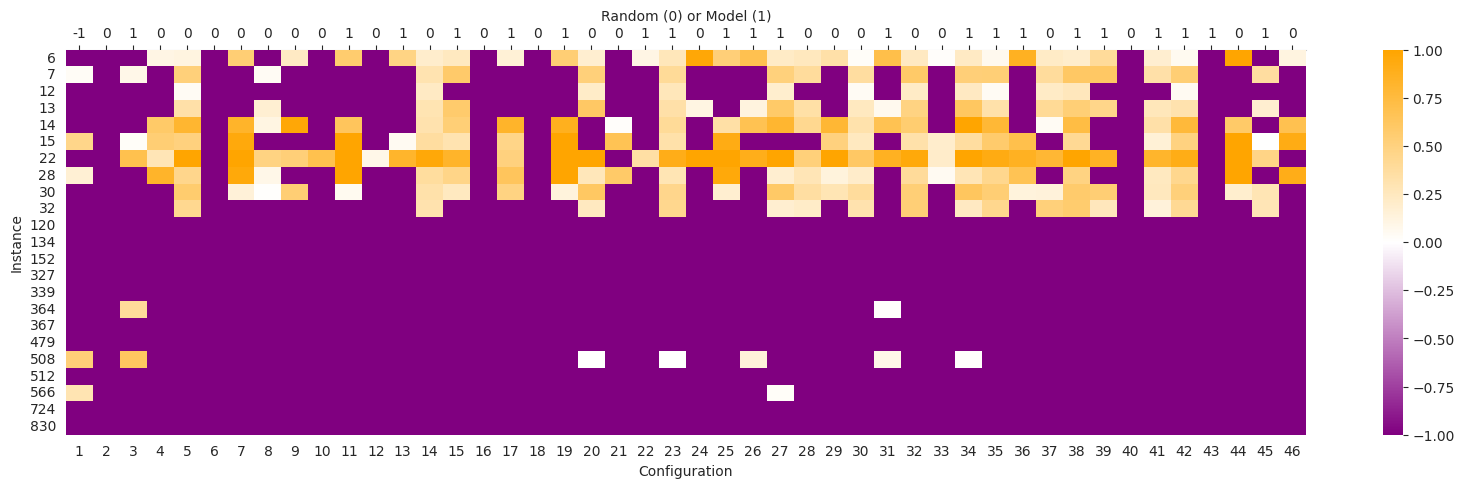

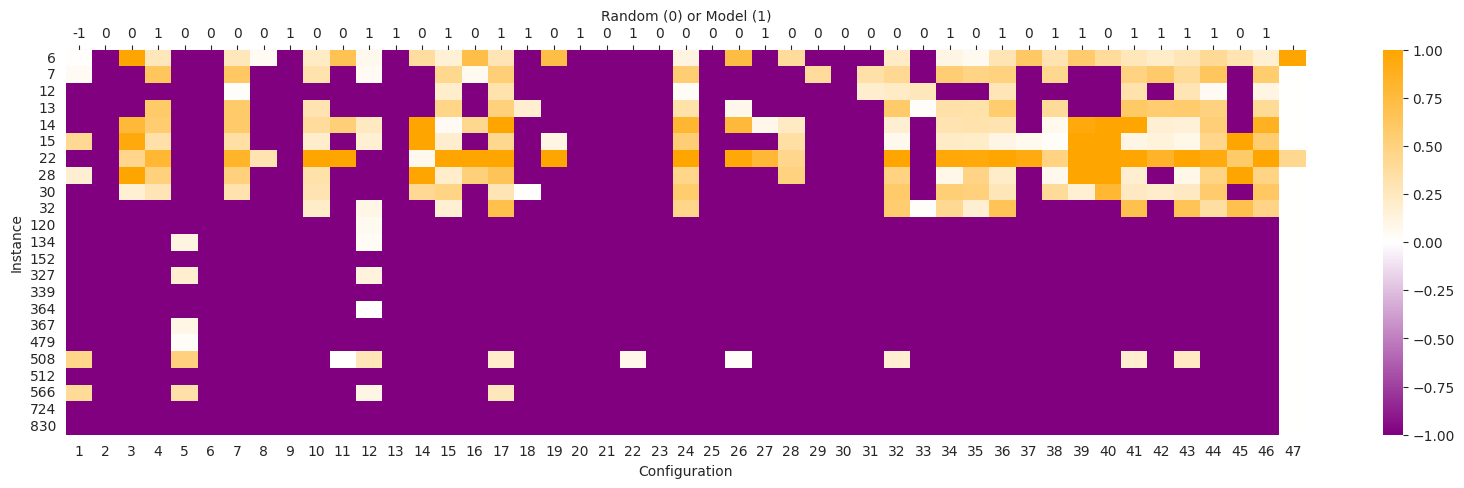

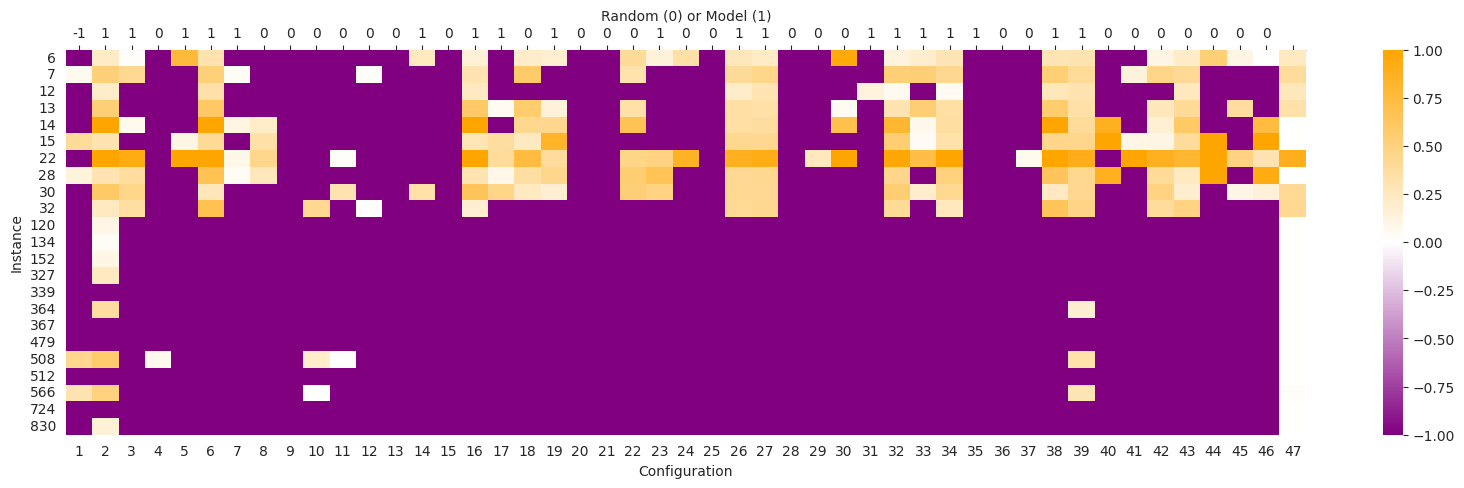

In [7]:
from matplotlib.colors import LinearSegmentedColormap


def get_random_or_model(map_loc):
    with open(f"{map_loc}/runhistory.json") as f:
        runhistory = json.load(f)

    encoded_ticks = []
    for config, origin in runhistory["config_origins"].items():
        if origin == "Random Search":
            encoded_ticks.append(0)
        elif origin == "Initial Design: Default":
            encoded_ticks.append(-1)
        else: # origin == "Acquisition Function Maximizer: Local Search":
            encoded_ticks.append(1)
    return encoded_ticks



def instance_csv_to_heatmap(map_loc, type_map="utility", captime=3600):
    all_instance_csv = pd.read_csv(f"{map_loc}/all_instances.csv")
    all_instance_csv = all_instance_csv.rename(columns={" Instance": "Instance"})
    # print(all_instance_csv.columns)
    # print(all_instance_csv[" Instance"])
    plt.rcParams["figure.figsize"] = (20,5)

    names = []
    for name in all_instance_csv["Instance"]:
        names.append(name.split("/")[-1][4:-3])
        # print(name.split("/")[-1][4:-3])

    all_instance_csv["Instance_Names"] = names

    # display(all_instance_csv.head())

    # print(all_instance_csv["Config_ID"].unique())
    # print(all_instance_csv["Instance_Names"].unique())

    config_map_dict = {}

    for i, config in enumerate(sorted(all_instance_csv["Config_ID"].unique())):
        config_map_dict[config] = i

    instance_map_dict = {}
    for i, instance_label in enumerate(sorted(all_instance_csv["Instance_Names"].unique(), key=lambda x: int(x))):
        instance_map_dict[instance_label] = i

    # print(instance_map_dict)

    # TODO: maybe sort by the average runtime over all configs?

    heatmap = np.zeros((len(config_map_dict), len(instance_map_dict)))

    for index, row in all_instance_csv.iterrows():
        # The utility in this file is not 1-util, but the acutal util, unlike in the run logs
        # print(row['c1'], row['c2'])
        if type_map == "utility" and row["Runtime"] >= captime:
            heatmap[config_map_dict[row["Config_ID"]], instance_map_dict[row["Instance_Names"]]] = -1
        else:
            heatmap[config_map_dict[row["Config_ID"]], instance_map_dict[row["Instance_Names"]]] = row["Utility"]
    # print(heatmap)

    # TODO: check transpose....
    cmap = LinearSegmentedColormap.from_list(
    "purple_orange_grad",
    ["purple", "white", "orange"],
    N=256
)

    ax = sns.heatmap(heatmap.T, cmap= cmap, #cmap=sns.cubehelix_palette(as_cmap=True),
                xticklabels=config_map_dict.keys(),yticklabels=instance_map_dict.keys())

    # Create a second x-axis at the top
    ax_top = ax.secondary_xaxis("top")
    ax_top.set_xlabel("Random (0) or Model (1)")

    # Place ticks at the centers of the heatmap cells
    positions = np.arange(heatmap.T.shape[1]) + 0.5

    ax_top.set_xticks(positions)
    # ax_top.set_xticklabels([1] * len(positions))
    top_ticks = get_random_or_model(map_loc)
    while len(top_ticks) != len(positions):
        top_ticks.append("")
    ax_top.set_xticklabels(top_ticks)


    plt.xlabel("Configuration")
    plt.ylabel("Instance")
    plt.show()



instance_csv_to_heatmap("storage_alice/smac3_23_set_3600/1/")
instance_csv_to_heatmap("storage_alice/smac3_23_set_3600/2/")
instance_csv_to_heatmap("storage_alice/smac3_23_set_3600/3/")

# TODO, Not overlay a top header of if it is a random sample or not with just a binary number at the top

The interesting observation here is that, consistently, the good configurations seems to be taken by the model, not the random ones. The model does on occasion suck, and the random is sometimes good, but almost consisntly the model finds bbetter performing configurations.

In [4]:
def get_random_vs_model(map_loc, captime=3600):
    all_instance_csv = pd.read_csv(f"{map_loc}/all_instances.csv")
    all_instance_csv = all_instance_csv.rename(columns={" Instance": "Instance"})

    names = []
    for name in all_instance_csv["Instance"]:
        names.append(name.split("/")[-1][4:-3])

    all_instance_csv["Instance_Names"] = names

    top_ticks = get_random_or_model(map_loc)

    #remember the +-1

    model_scores_runtime = []
    random_scores_runtime = []

    model_scores_utility = []
    random_scores_utility = []

    model_timeouts = []
    random_timeouts = []

    model_PAR10 = []
    random_PAR10 = []


    for name, group in all_instance_csv.groupby("Config_ID"):
        # print(group)
        # print(name)
        try:
            if top_ticks[name-1] == 1:
                model_scores_utility.append(group["Utility"].mean())
                model_scores_runtime.append(group["Runtime"].mean())
                model_timeouts.append(len(group[group["Runtime"] >= captime]))
                group.loc[group["Runtime"] >= captime, "Runtime"] = captime * 10
                model_PAR10.append((group["Runtime"].mean()))
            elif top_ticks[name-1] == 0:
                random_scores_utility.append(group["Utility"].mean())
                random_scores_runtime.append(group["Runtime"].mean())
                random_timeouts.append(len(group[group["Runtime"] >= captime]))
                # print(group["Runtime"] >= captime)
                group.loc[group["Runtime"] >= captime, "Runtime"] = captime * 10
                random_PAR10.append((group["Runtime"].mean()))
        except IndexError as e:
            continue

    print(f"Stats for: {map_loc}")
    print(f"Mean Random Runtime: {np.mean(random_scores_runtime)}")
    print(f"Mean Random Utility: {np.mean(random_scores_utility)}")
    print(f"Mean Model Runtime: {np.mean(model_scores_runtime)}")
    print(f"Mean Model Utility: {np.mean(model_scores_utility)}")

    print(f"Mean Random Timeouts: {np.mean(random_timeouts)}")
    print(f"Mean Model Timeouts: {np.mean(model_timeouts)}")

    print(f"Mean Random PAR10: {np.mean(random_PAR10)}")
    print(f"Mean Model PAR10: {np.mean(model_PAR10)}")



get_random_vs_model("storage_alice/smac3_23_set_3600/1/")
print("\n")
get_random_vs_model("storage_alice/smac3_23_set_3600/2/")
print("\n")
get_random_vs_model("storage_alice/smac3_23_set_3600/3/")

# TODO, Not overlay a top header of if it is a random sample or not with just a binary number at the top

Stats for: storage_alice/smac3_23_set_3600/1/
Mean Random Runtime: 3153.2213461956526
Mean Random Utility: 0.0912143390441751
Mean Model Runtime: 2933.821922567288
Mean Model Utility: 0.1389025934209623
Mean Random Timeouts: 18.25
Mean Model Timeouts: 16.285714285714285
Mean Random PAR10: 28861.005404166663
Mean Model PAR10: 25874.64121863354


Stats for: storage_alice/smac3_23_set_3600/2/
Mean Random Runtime: 3186.3685302675585
Mean Random Utility: 0.08847100447456392
Mean Model Runtime: 2991.5780901601834
Mean Model Utility: 0.12001780419437601
Mean Random Timeouts: 18.76923076923077
Mean Model Timeouts: 16.263157894736842
Mean Random PAR10: 29625.568446655518
Mean Model PAR10: 25900.617266361554


Stats for: storage_alice/smac3_23_set_3600/3/
Mean Random Runtime: 3337.0378872909696
Mean Random Utility: 0.053889874782421875
Mean Model Runtime: 2897.0289764302056
Mean Model Utility: 0.13546555138172173
Mean Random Timeouts: 20.115384615384617
Mean Model Timeouts: 15.578947368421053
Me

The difference is also not even greatly visible in the PAR10 due to the extreme number of timeouts... again poining at multi objective being a good idea

Utility does seem to show this difference the best tho, together with the number of timeouts